In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys

from scipy.optimize import curve_fit
import scipy
from tqdm import tqdm

from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
print(cosmo.h, cosmo.Hz(redshift), cosmo.H0*cosmo.Ez(redshift))

sys.path.append('/home/cosweeney/code/Fits/')

sys.path.append('/home/cosweeney/code/Fits/Jocond')

from JoCond.jocond.losvd import *
from JoCond.jocond.cat import *
from JoCond.jocond.mass_calibration import *

import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})

0.6777 74.71913613009617 74.71913613009617


In [2]:
# bin MDPL2 data 

# Mass bin centers
Rvirs, Mvirs, mbins = compute_bin_virial_R_M('/spiff/cosweeney/Tables/halo_pair_cat_final2_HD.hdf5')

# radial bins
r_edges = np.linspace(5, 15, (15-5)+1)
r_cens = (r_edges[1:]+r_edges[:-1])/2.0

vel_path = '/spiff/cosweeney/simulations/MDPL2/data/r_R_rlos_vpeclos_vphyslos_data_mass_100_cyl_6K_indmass.hdf5'

vpeclos_ls  = []
vphyslos_ls = []
rlos_ls = []
R_ls = []
M_ls = []

with h5.File(vel_path, 'r') as hdf:
    for k, M in enumerate(Mvirs):
        rel_R = hdf[f'R/{k}'][()]
        rel_rlos = hdf[f'rlos/{k}'][()]
        vpec = hdf[f'vpeclos/{k}'][()]
        vphys = hdf[f'vphyslos/{k}'][()]
        Mvir = hdf[f'Mvir/{k}'][()]
        
        # Use digitize to bin all at once
        bin_indices = np.digitize(rel_R, r_edges) - 1
        
        for i in range(len(r_cens)):
            mask = bin_indices == i
            vpeclos_ls.append(vpec[mask])
            vphyslos_ls.append(vphys[mask])
            rlos_ls.append(rel_rlos[mask])
            R_ls.append(rel_R[mask])
            M_ls.append(Mvir[mask])

massbin edges, in h^-1 sol mass: [8.00020227e+13 1.22732852e+14 1.88287152e+14 2.88855436e+14
 4.43139440e+14 6.79829904e+14 1.60000000e+15]


In [3]:
# bin 'bin mass' model samples
samp_path = '/spiff/cosweeney/simulations/MDPL2/data/Pvlos_models/gal_model_bin_mass_samples_r_4_15.hdf5'
#'/spiff/cosweeney/simulations/MDPL2/data/Pvlos_models/gal_model_bin_mass_samples_r_4_30.hdf5'

#vpeclos_bin  = []
vphyslos_bin = []
#rlos_bin = []
#R_bin = []

for k, M in enumerate(Mvirs):
    for i, R in enumerate(r_cens):
        #if k == 0 and i < 16 or k > 0:
        with h5.File(samp_path, 'r') as hdf:
            #rel_R = hdf[f'R/{str(k)}/{str(i)}'][()]
            #rel_rlos = hdf[f'rlos/{str(k)}/{str(i)}'][()]
            #vpec = hdf[f'vpeclos/{str(k)}/{str(i)}'][()]
            vphys = hdf[f'vphyslos/{str(k)}/{str(i+1)}'][()] # saved samples have an extra radial bin at r=4

        #vpeclos_bin.append(vpec)
        vphyslos_bin.append(vphys)
        #rlos_bin.append(rel_rlos)
        #R_bin.append(rel_R)
        # else:
        #     vpeclos_bin.append(np.array([]))
        #     vphyslos_bin.append(np.array([]))
        #     rlos_bin.append(np.array([]))
        #     R_bin.append(np.array([]))

In [4]:
# compute histograms
bin_num = 50 

LOS_hists_MDPL2 = np.zeros((bin_num, len(Mvirs), len(r_cens)))
LOS_hists_bin = np.zeros((bin_num, len(Mvirs), len(r_cens)))
#LOS_hists_ind = np.zeros((bin_num, len(Mvirs), len(r_cens)))

vedges = np.linspace(-2500, 2500, bin_num+1)
vcens = 0.5*(vedges[1:]+vedges[:-1])


for k in range(len(Mvirs)):
    for i in range(len(r_cens)):
        index = i + len(r_cens)*k
        #samp_index = i + len(r_cens)*k


        hist, v_edges = np.histogram(vphyslos_ls[index], bins=bin_num, range=[-2500, 2500], density=False)
        hist_bin, v_edges = np.histogram(vphyslos_bin[index], bins=bin_num, range=[-2500, 2500], density=False)
 #       hist_ind, v_edges = np.histogram(vphyslos_ind[index], bins=bin_num, range=[-2500, 2500], density=False)

        v_cens = (v_edges[:-1] + v_edges[1:]) / 2 

        LOS_hists_MDPL2[:, k, i] = hist  
        LOS_hists_bin[:, k, i] = hist_bin  
  #      LOS_hists_ind[:, k, i] = hist_ind 

LOS_hists = [LOS_hists_MDPL2, LOS_hists_bin] #, LOS_hists_ind

In [5]:
# compute # of halos in each mass bin
halo_path = '/spiff/cosweeney/simulations/MDPL2/hlists/hlist_0.83760_update.hdf5'

N_halos = np.zeros(len(Mvirs))
with h5.File(halo_path, 'r') as hcat:
    for k in range(len(mbins)-1):
        mcut = (hcat['mvir'] > mbins[k]) & (hcat['mvir'] <= mbins[k+1])

        N_bin = mcut.sum()

        N_halos[k] = N_bin

In [6]:
r_fine_edges = np.linspace(5, 50, 100)
r_fine_cens = 0.5*(r_fine_edges[1:]+r_fine_edges[:-1])

rho_RM = np.zeros((6, len(r_fine_cens)))

with h5.File(vel_path, 'r') as hdf:

    for k in range(len(Mvirs)):
        
        rs = hdf[f'r/{str(k)}'][()]

        for j in range(len(r_fine_cens)):
            
            r_mask = (rs >= r_fine_edges[j])&(rs <= r_fine_edges[j+1])

            N_pairs = r_mask.sum()

            V_shell = 4/3 *  np.pi * ( r_fine_edges[j+1]**3 - r_fine_edges[j]**3 ) 

            rho = N_pairs / N_halos[k] / V_shell 

            rho_RM[k, j] = rho

In [7]:
from JoCond.jocond.hgcf import *
from JoCond.jocond.myconfig import * 

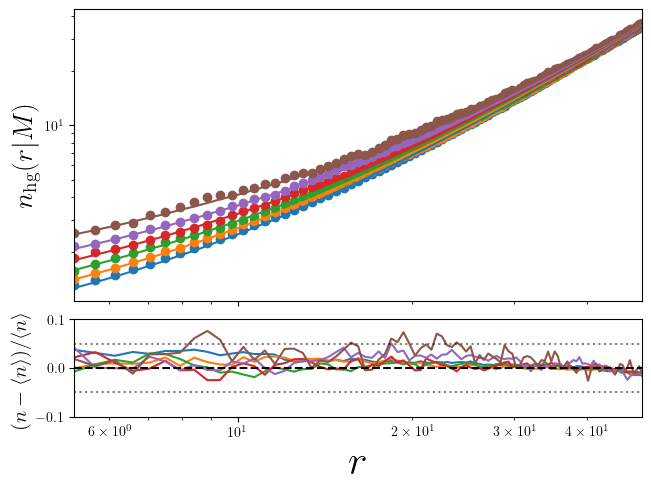

In [13]:
fig, ax = plt.subplots(2, 1, layout='constrained', sharex=1, gridspec_kw={'height_ratios': [3, 1]})

n_gal = 0.014

for k in range(len(Mvirs)):
    rho = n_gal*(1+cf_inf(r_fine_cens, Mvirs[k], cf_pars)) 
    ax[0].scatter(r_fine_cens, r_fine_cens**2*rho_RM[k], label=r'MDPL2')
    ax[0].plot(r_fine_cens, r_fine_cens**2*rho, label=r'MAP Model')

    ax[1].plot(r_fine_cens, (rho_RM[k] - rho)/rho)

ax[0].set_yscale('log')
ax[0].set_xscale('log')

ax[1].axhline(0, c='k', ls='--') 
ax[1].axhline(-0.05, c='k', ls=':', alpha=0.5) 
ax[1].axhline(0.05, c='k', ls=':', alpha=0.5) 

ax[1].set_xscale('log')
ax[1].set_ylim((-0.1, 0.1))

ax[0].set_ylabel(r'$n_{\rm hg}(r|M)$', fontsize=20)
ax[1].set_ylabel(r'$(n - \langle n \rangle )/\langle n \rangle$', fontsize=15)
ax[1].set_xlabel(r'$r$', fontsize=30)

ax[0].margins(x=0)
ax[1].margins(x=0)

In [5]:
# rescale by conversion factor for DESI estimates

# DESI BGS Estimation
from colossus.cosmology import cosmology

C = cosmology.setCosmology('planck13')
#C = cosmology.Cosmology

Area_deg = 1e4 #deg^2
Area_sr = Area_deg / (180.0/np.pi)**2 

z_1 = 0.1
z_2 = 0.4
delta_z = z_2 - z_1

d_1 = C.comovingDistance(z_min=0.0, z_max=z_1)
d_2 = C.comovingDistance(z_min=0.0, z_max=z_2)

V_DESI = ( Area_sr / 3 ) * ( d_2**3 - d_1**3) # h^-3 Mpc^3

V_MDPL2 = 1000**3 # h^-3 Mpc^3
#n_MDPL2 = 0.014 / cosmo.h**3 # num of galaxies in box / V_MDPL2 in Mpc^-3 
n_MDPL2 = 0.014 # num of galaxies in box / V_MDPL2 in h^3 Mpc^-3 

n_BGS = 1e-3 # h^3 Mpc^-3

N_MDPL2 = np.sum(LOS_hists_MDPL2) 
N_est = N_MDPL2 * V_DESI * n_BGS / V_MDPL2 / n_MDPL2 

conv_BGS = V_DESI * n_BGS / V_MDPL2 / n_MDPL2 


BGS_hists = [LOS_hist*conv_BGS for LOS_hist in LOS_hists]

# DESI LRG Estimation

z_1 = 0.4
z_2 = 0.8
delta_z = z_2 - z_1

d_1 = C.comovingDistance(z_min=0.0, z_max=z_1)
d_2 = C.comovingDistance(z_min=0.0, z_max=z_2)

V_DESI = ( Area_sr / 3 ) * ( d_2**3 - d_1**3) # h^-3 Mpc^3

n_LRG = 4.5e-4 # h^3 Mpc^-3 

N_MDPL2 = np.sum(LOS_hists_MDPL2) 
N_est = N_MDPL2 * V_DESI * n_LRG / V_MDPL2 / n_MDPL2 

conv_LRG = V_DESI * n_LRG / V_MDPL2 / n_MDPL2 

LRG_hists = [LOS_hist*conv_LRG for LOS_hist in LOS_hists]

In [8]:
# fit using mass_calibration class
M_edges = np.logspace(np.log10(0.80), np.log10(11), 50) # grid of Mvals
Mvals = np.sqrt(M_edges[1:] * M_edges[:-1])
M_p = 1e14  # h^-1 M_sun

mc = MassCalibrator(r_cens, 
                    Mvirs, 
                    mbins, 
                    vedges, 
                    LOS_hists_MDPL2, 
                    grid_path='/spiff/cosweeney/simulations/MDPL2/data/Pvlos_simdens_M_grid_R_5_15_gal.npy', 
                    Mvals=Mvals)

In [9]:
mc.calibrate_full(print_mess=False)

Fitting individual R bins...
Fitting bins simultaneously...


In [65]:
mc.fit_simultaneous()

Fitting individual R bins...


/home/cosweeney/code/Fits/JoCond/jocond/mass_calibration.py:114: RuntimeWarning: invalid value encountered in log
  return - 0.5 * np.sum(chisq + np.log(sigmasq))


Text(0.5, 1.0, 'Fit of Analytic Model with sim densities, MDPL2 Gals')

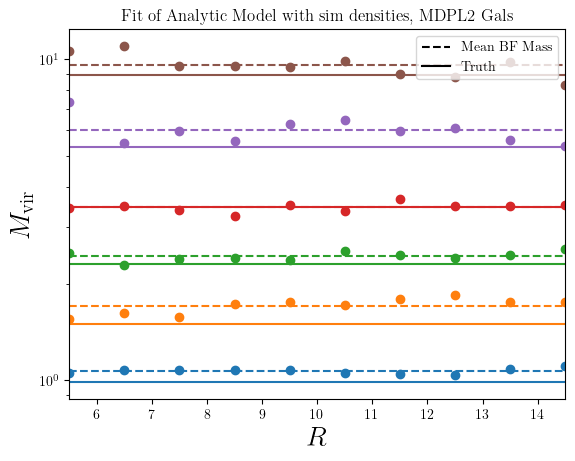

In [21]:
mc.plot_indiv_fits()

plt.title(r"Fit of Analytic Model with sim densities, MDPL2 Gals")

Text(0.5, 1.0, 'Fit of Analytic Model with sim densities, MDPL2 Gals')

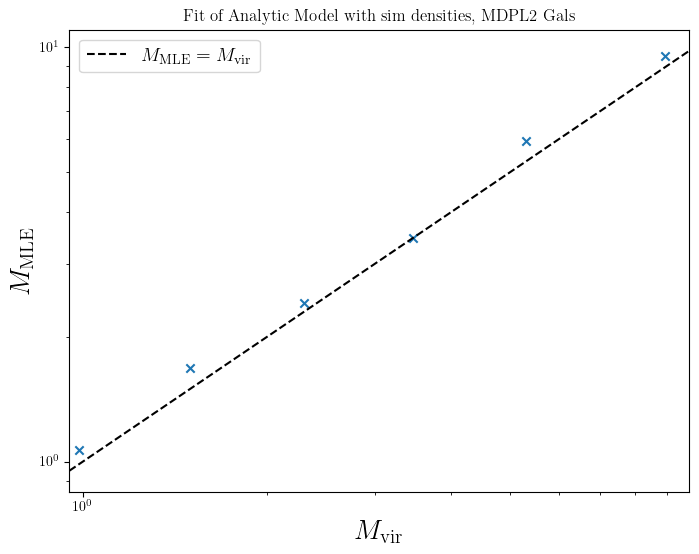

In [22]:
mc.plot_simult_fits()

plt.title(r"Fit of Analytic Model with sim densities, MDPL2 Gals")

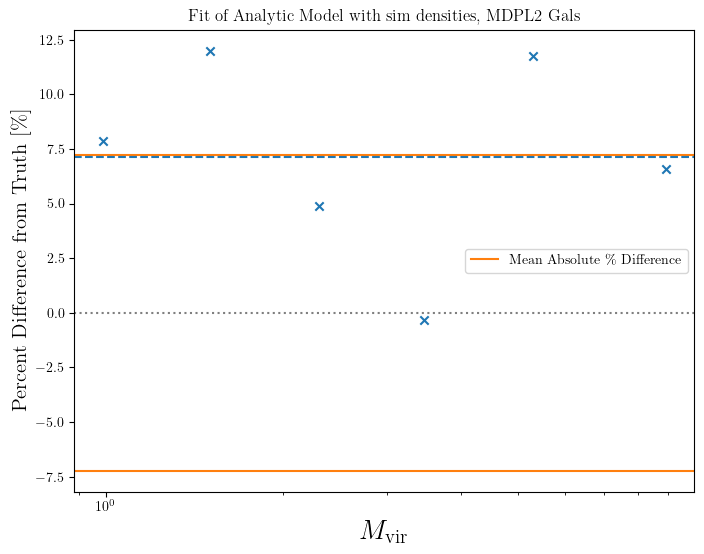

In [34]:
mc.plot_per_diff()
plt.title(r"Fit of Analytic Model with sim densities, MDPL2 Gals")
plt.axhline(np.mean((mc.par_mass_sim[:-1] - mc.mvirs )/mc.mvirs)*100, c='C0', ls='--')


In [51]:
M_edges = np.logspace(np.log10(0.80), np.log10(11), 20) # grid of Mvals
Mvals = np.sqrt(M_edges[1:] * M_edges[:-1])
M_p = 1e14  # h^-1 M_sun

In [52]:
n_gal = 0.014 # (Mpc/h)^-3
rmax = 40
rlos_edges = np.linspace(-rmax, rmax, int(rmax)+1)
rlos_cens = (rlos_edges[1:]+rlos_edges[:-1])/2.0

N_R_rlos = np.zeros((len(Mvals), len(r_cens), len(rlos_cens)))

R_widths = r_edges[1:] - r_edges[:-1]
rlos_widths = rlos_edges[1:] - rlos_edges[:-1]
R_grid, rlos_grid = np.meshgrid(r_cens, rlos_cens, indexing='ij')
bin_vols = 2 * np.pi * R_grid * R_widths[:, None] * rlos_widths[None, :]

with h5.File(vel_path, 'r') as hdf:
    for k, M in tqdm(enumerate(Mvirs)):
        rel_R = hdf[f'R/{str(k)}'][()]
        rel_rlos = hdf[f'rlos/{str(k)}'][()]
        bin_Mvir = hdf[f'Mvir/{str(k)}'][()]

        for j, m in enumerate(Mvals):
            mask = (bin_Mvir >= M_edges[j]*M_p) & (bin_Mvir < M_edges[j+1]*M_p)

            if np.sum(mask) > 0:
                N_R_rlos[j], _, _ = np.histogram2d(rel_R[mask], rel_rlos[mask], bins=[r_edges, rlos_edges], density=False)



0it [00:00, ?it/s]

6it [01:12, 12.01s/it]


In [69]:

def P_vphys_R_simdens(vphys, i, k, pars=jocond.myconfig.joint_MAP, H=74.719, a=0.83760, h=0.6777):

    R = r_cens[i]
    M = Mvals[k]*1e14 

    # rlos integration range
    rlos_max = 40 
    rlos_edges = np.linspace(-rlos_max, rlos_max, int(rlos_max + 1))
    rlos_cens = 0.5 * (rlos_edges[1:] + rlos_edges[:-1])

    rlos_vals = rlos_cens

    vpec = vphys[:, None] - a * H * rlos_vals[None, :] / h

    vr_e = np.linspace(-4000, 4000, 100)
    vr_grid = 0.5 * (vr_e[1:] + vr_e[:-1])

    Pvlos_grid = np.array(
        [P_vlos_R_rlos(vr_grid, R, rlos, M, pars) for rlos in rlos_vals]
    )

    Pvlos_interp_list = []

    for j in range(len(rlos_vals)):
        interp_func = interp1d(
            vr_grid, Pvlos_grid[j], kind="linear", bounds_error=False, fill_value=0.0
        )
        interpolated = interp_func(vpec[:, j])

        Pvlos_interp_list.append(interpolated)

    Pvlos_interp = np.array(Pvlos_interp_list)
    Pvlos_interp = Pvlos_interp.T

    #r3d = np.sqrt(R**2 + rlos_vals**2)
    #k = np.where(M/1e14 == Mvals)[0][0]
    #i = np.where(r_cens == R)[0][0]
    weight = N_R_rlos[k, i] / bin_vols[i] #rho_g * (cf_inf(r3d, M, jocond.myconfig.cf_pars) + 1)

    integrand = Pvlos_interp * weight[None, :]
    P_out = simpson(integrand, x=rlos_vals, axis=1)

    sigma_R = Sigma_inf(R, M, jocond.myconfig.cf_pars)
    P_out /= sigma_R

    return P_out / np.sum(P_out * np.diff(vphys)[0])

In [34]:

r_select_inds = [0, 5, 9]
r_select = np.array([r_cens[i] for i in r_select_inds]) 

In [58]:
i = 0
k = 0

model_sd = P_vphys_R_simdens(vcens, r_cens[r_select_inds[i]], Mvals[inds[k]]*1e14)
model_an = P_vphys_R(vcens, r_cens[r_select_inds[i]], Mvals[inds[k]]*1e14)

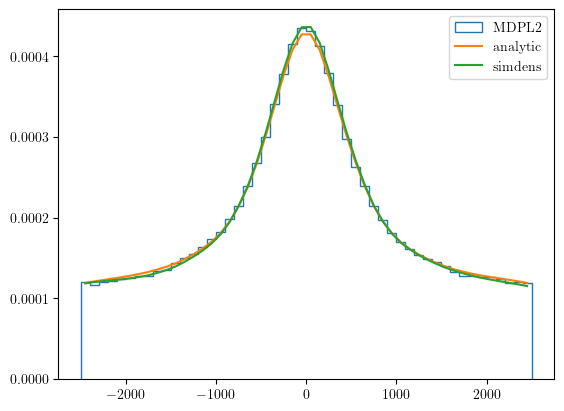

In [59]:
index = r_select_inds[i] + k*len(r_cens)
hist, bins_ex, _ = plt.hist(vphyslos_ls[index], bins=bin_num, range=[-2500, 2500], density=True, histtype='step', label='MDPL2')
plt.plot(vcens, model_an, label='analytic')
plt.plot(vcens, model_sd, label='simdens')
plt.legend()

In [14]:
def closest_argmin(A, B):
    L = B.size
    sidx_B = B.argsort()
    sorted_B = B[sidx_B]
    sorted_idx = np.searchsorted(sorted_B, A)
    sorted_idx[sorted_idx==L] = L-1
    mask = (sorted_idx > 0) & \
    ((np.abs(A - sorted_B[sorted_idx-1]) < np.abs(A - sorted_B[sorted_idx])) )
    return sidx_B[sorted_idx-mask]

inds = closest_argmin(Mvirs/1e14, Mvals)

In [17]:

# compute # of halos in each mass bin
halo_path = '/spiff/cosweeney/simulations/MDPL2/hlists/hlist_0.83760_update.hdf5'

N_halos = np.zeros(len(Mvirs))
with h5.File(halo_path, 'r') as hcat:
    for k in range(len(mbins)-1):
        mcut = (hcat['mvir'] > mbins[k]) & (hcat['mvir'] <= mbins[k+1])

        N_bin = mcut.sum()

        N_halos[k] = N_bin

r_fine_edges = np.linspace(5, 50, 100)
r_fine_cens = 0.5*(r_fine_edges[1:]+r_fine_edges[:-1])

rho_RM = np.zeros((6, len(r_fine_cens)))

with h5.File(vel_path, 'r') as hdf:

    for k in range(len(Mvirs)):
        
        rs = hdf[f'r/{str(k)}'][()]

        for j in range(len(r_fine_cens)):
            
            r_mask = (rs >= r_fine_edges[j])&(rs <= r_fine_edges[j+1])

            N_pairs = r_mask.sum()

            V_shell = 4/3 *  np.pi * ( r_fine_edges[j+1]**3 - r_fine_edges[j]**3 ) 

            rho = N_pairs / N_halos[k] / V_shell 

            rho_RM[k, j] = rho

rho_interp = RegularGridInterpolator((Mvirs, r_fine_cens), rho_RM, method='cubic', bounds_error=False, fill_value=None)

def P_vphys_R_simdens(vphys, R, M, pars=jocond.myconfig.joint_MAP, H=74.719, a=0.83760, h=0.6777):

    #R = r_cens[i]
    #M = Mvals[k]*1e14 

    # rlos integration range
    rlos_max = 40 
    rlos_edges = np.linspace(-rlos_max, rlos_max, int(rlos_max + 1))
    rlos_cens = 0.5 * (rlos_edges[1:] + rlos_edges[:-1])

    rlos_vals = rlos_cens

    vpec = vphys[:, None] - a * H * rlos_vals[None, :] / h

    vr_e = np.linspace(-4000, 4000, 100)
    vr_grid = 0.5 * (vr_e[1:] + vr_e[:-1])

    Pvlos_grid = np.array(
        [P_vlos_R_rlos(vr_grid, R, rlos, M, pars) for rlos in rlos_vals]
    )

    Pvlos_interp_list = []

    for j in range(len(rlos_vals)):
        interp_func = interp1d(
            vr_grid, Pvlos_grid[j], kind="linear", bounds_error=False, fill_value=0.0
        )
        interpolated = interp_func(vpec[:, j])

        Pvlos_interp_list.append(interpolated)

    Pvlos_interp = np.array(Pvlos_interp_list)
    Pvlos_interp = Pvlos_interp.T

    r3d = np.sqrt(R**2 + rlos_vals**2)
    #k = np.where(M/1e14 == Mvals)[0][0]
    #i = np.where(r_cens == R)[0][0]
    weight = np.array([rho_interp((M, ri)) for ri in r3d]) #N_R_rlos[k, i] / bin_vols[i] #rho_g * (cf_inf(r3d, M, jocond.myconfig.cf_pars) + 1)

    integrand = Pvlos_interp * weight[None, :]
    P_out = simpson(integrand, x=rlos_vals, axis=1)

    sigma_R = Sigma_inf(R, M, jocond.myconfig.cf_pars)
    P_out /= sigma_R

    return P_out / np.sum(P_out * np.diff(vphys)[0])


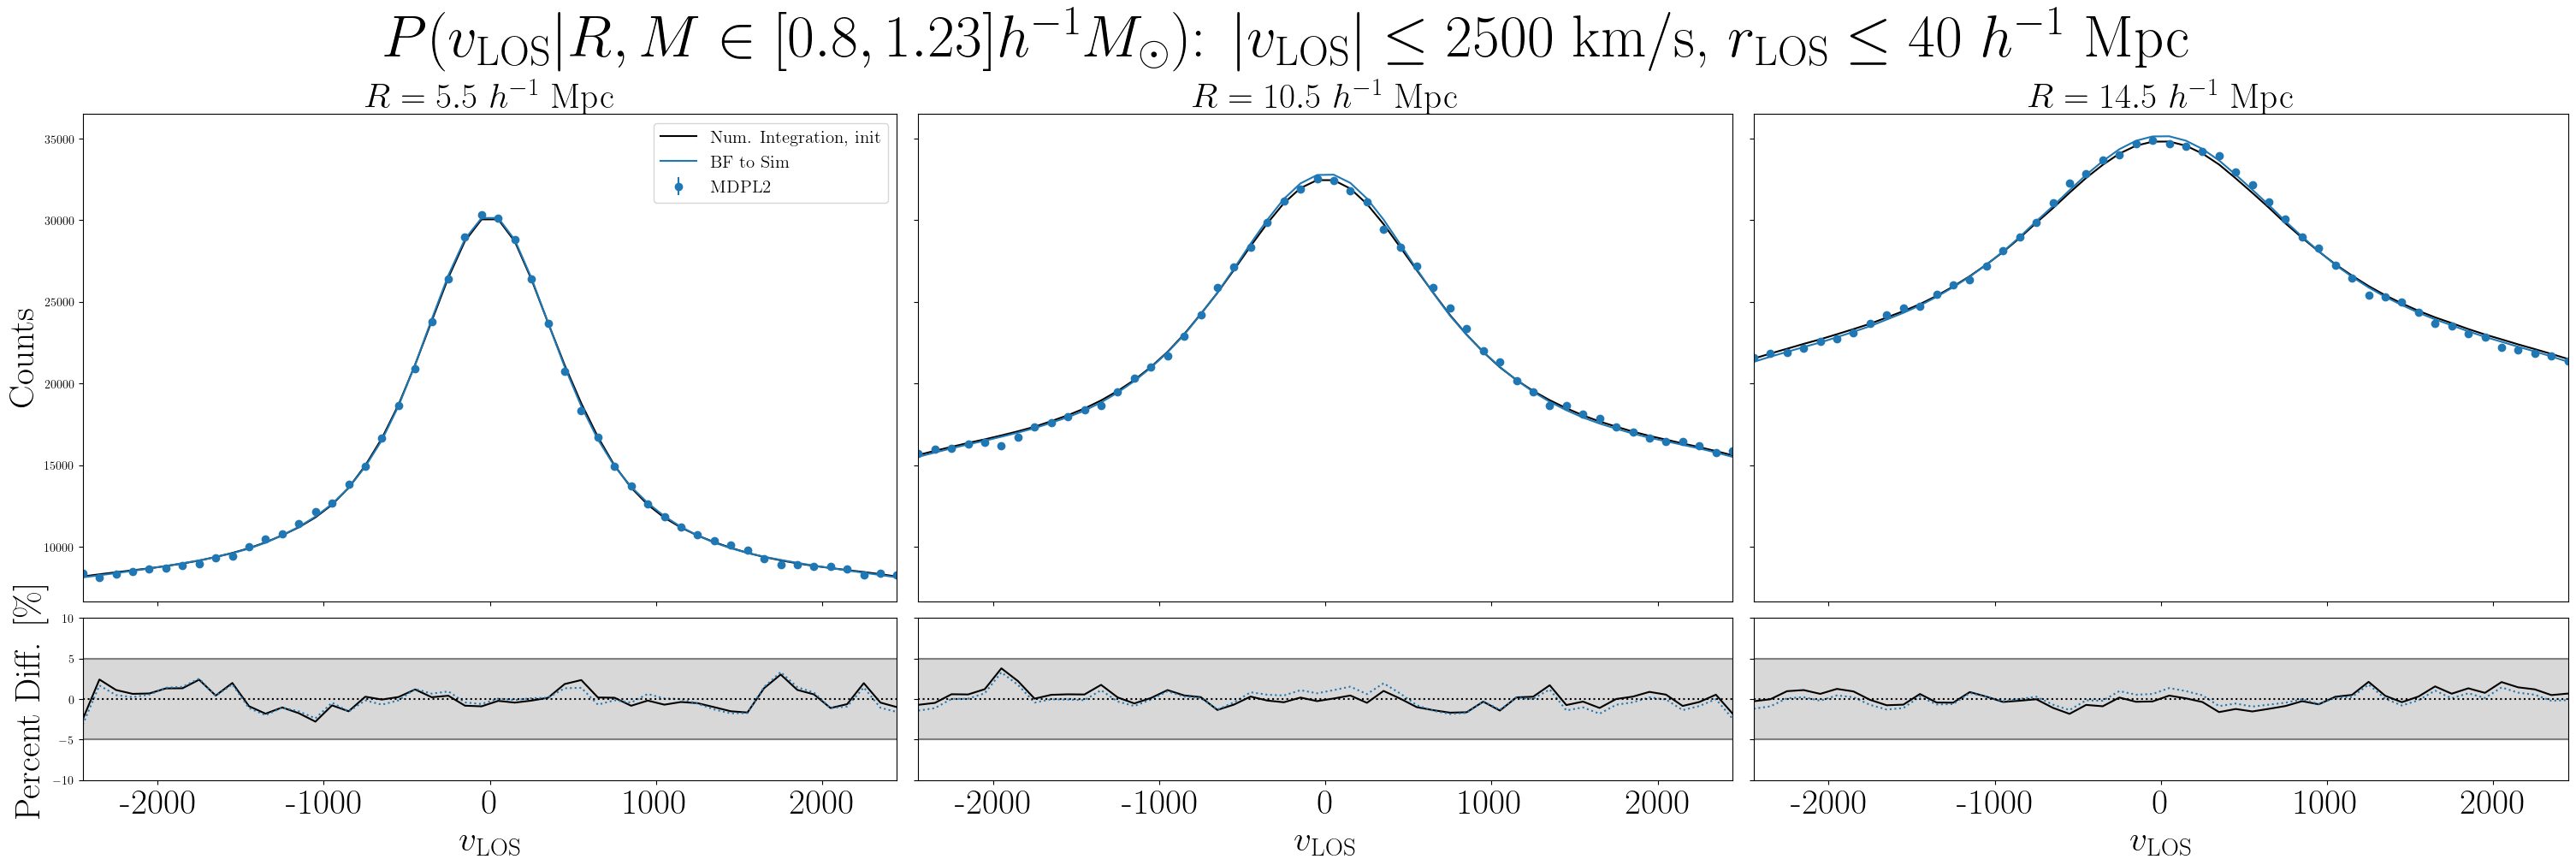

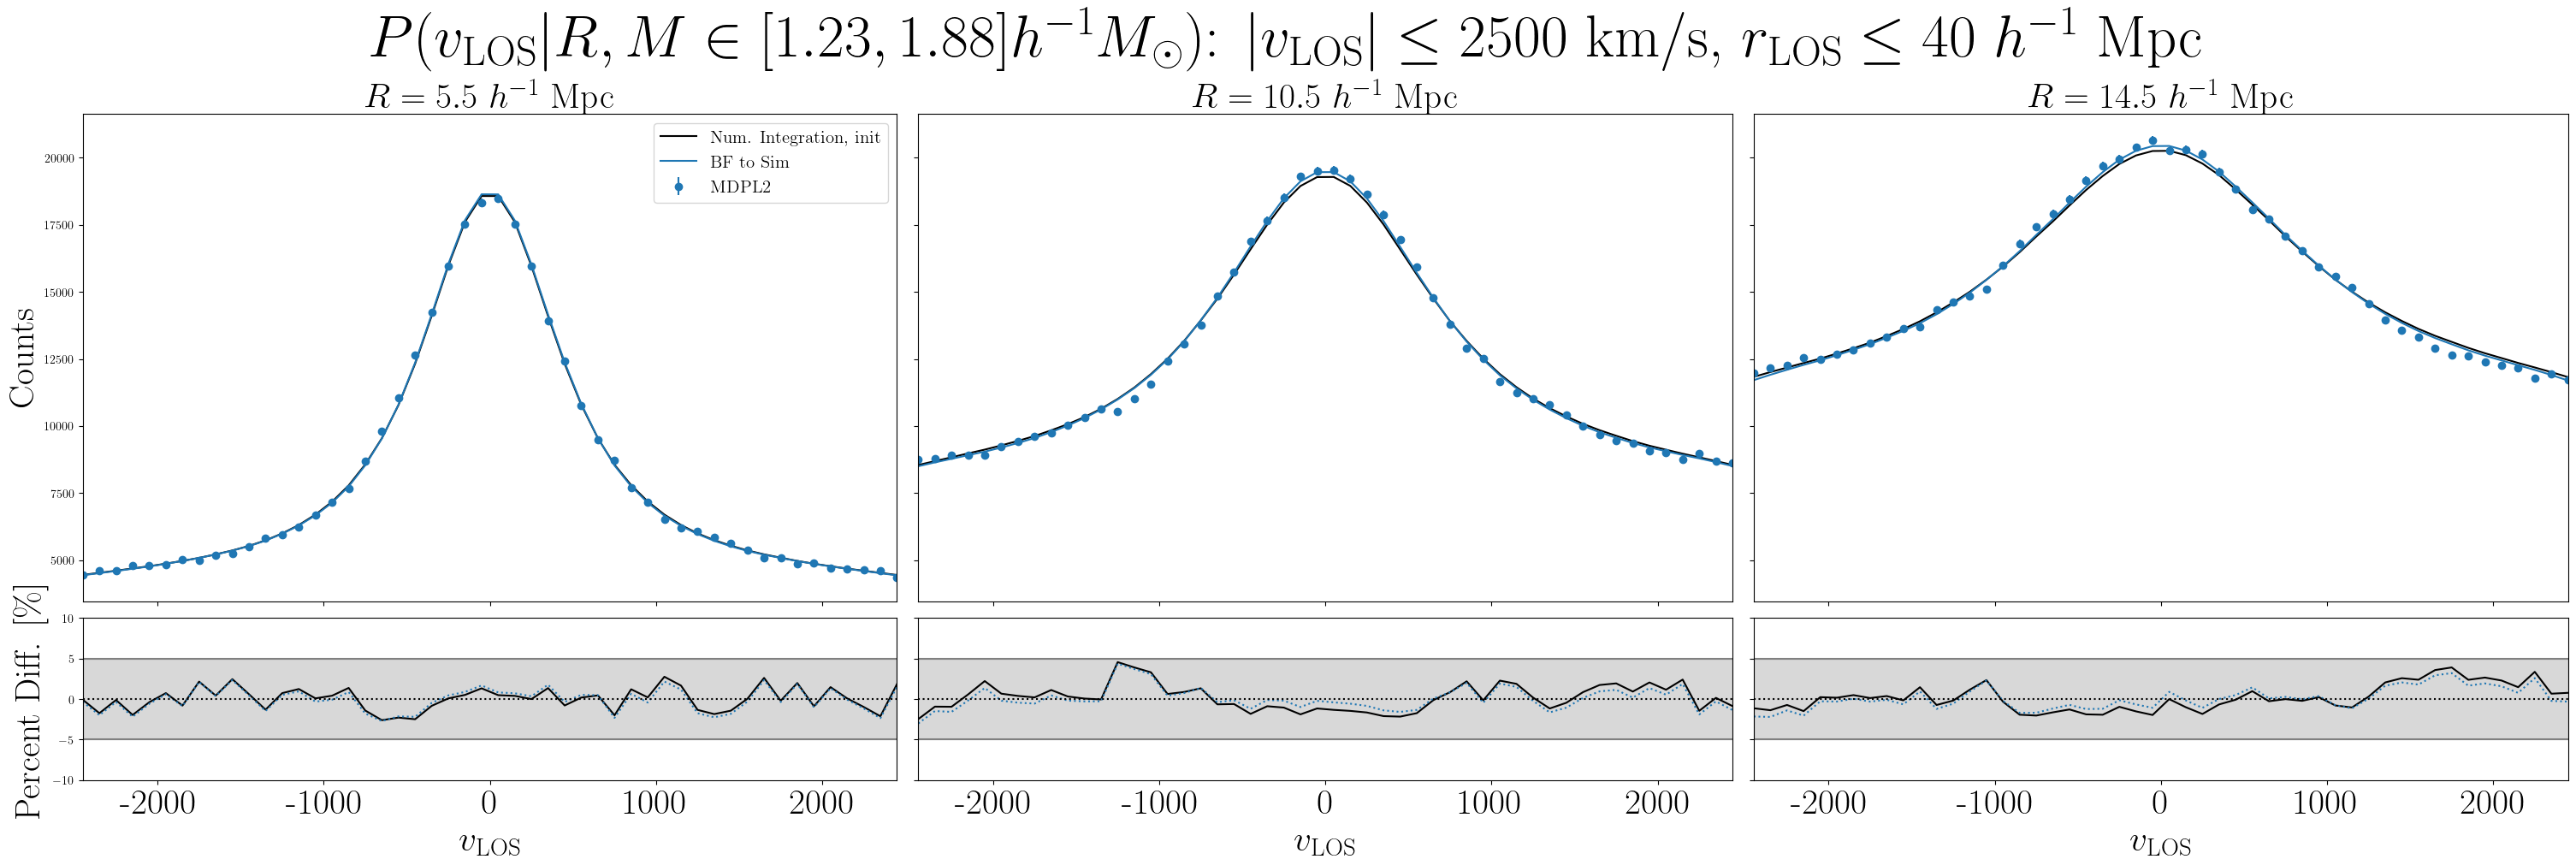

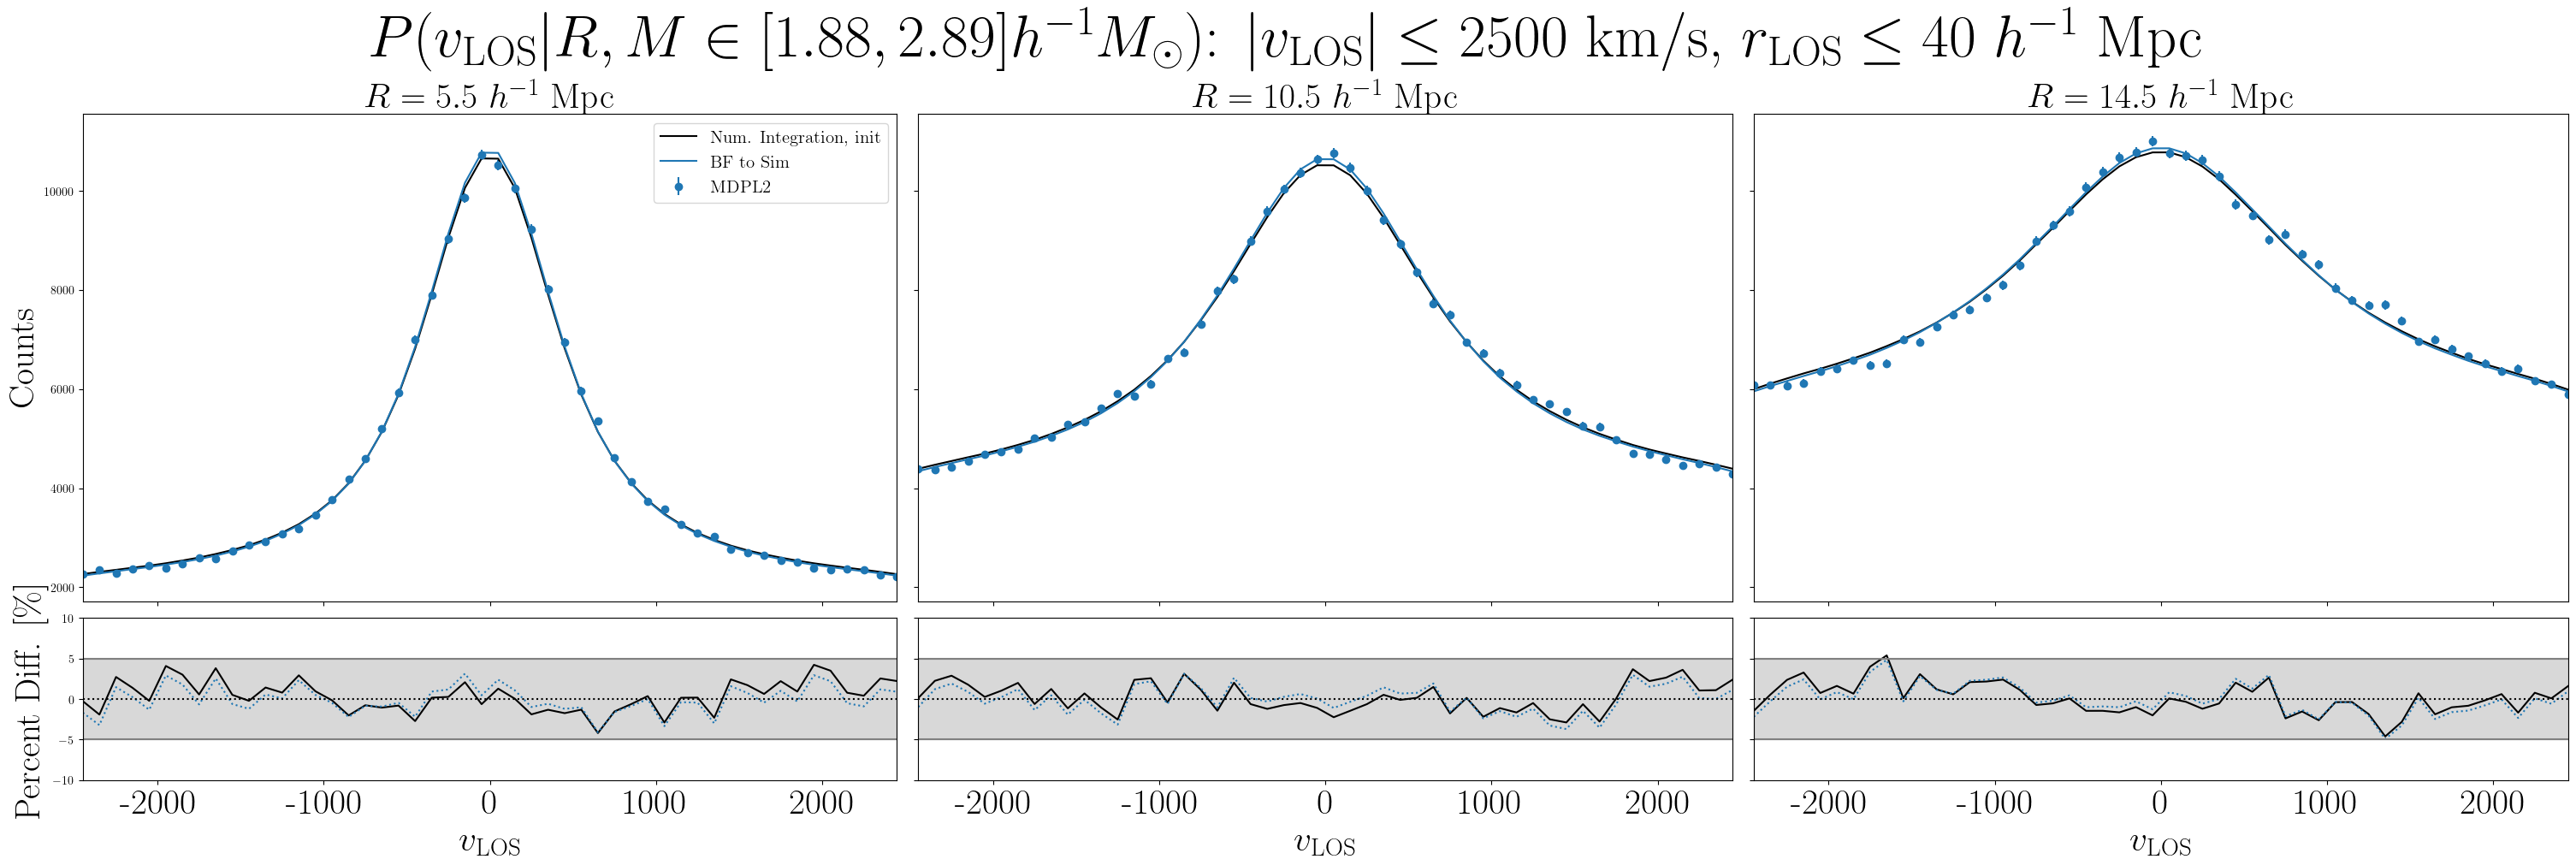

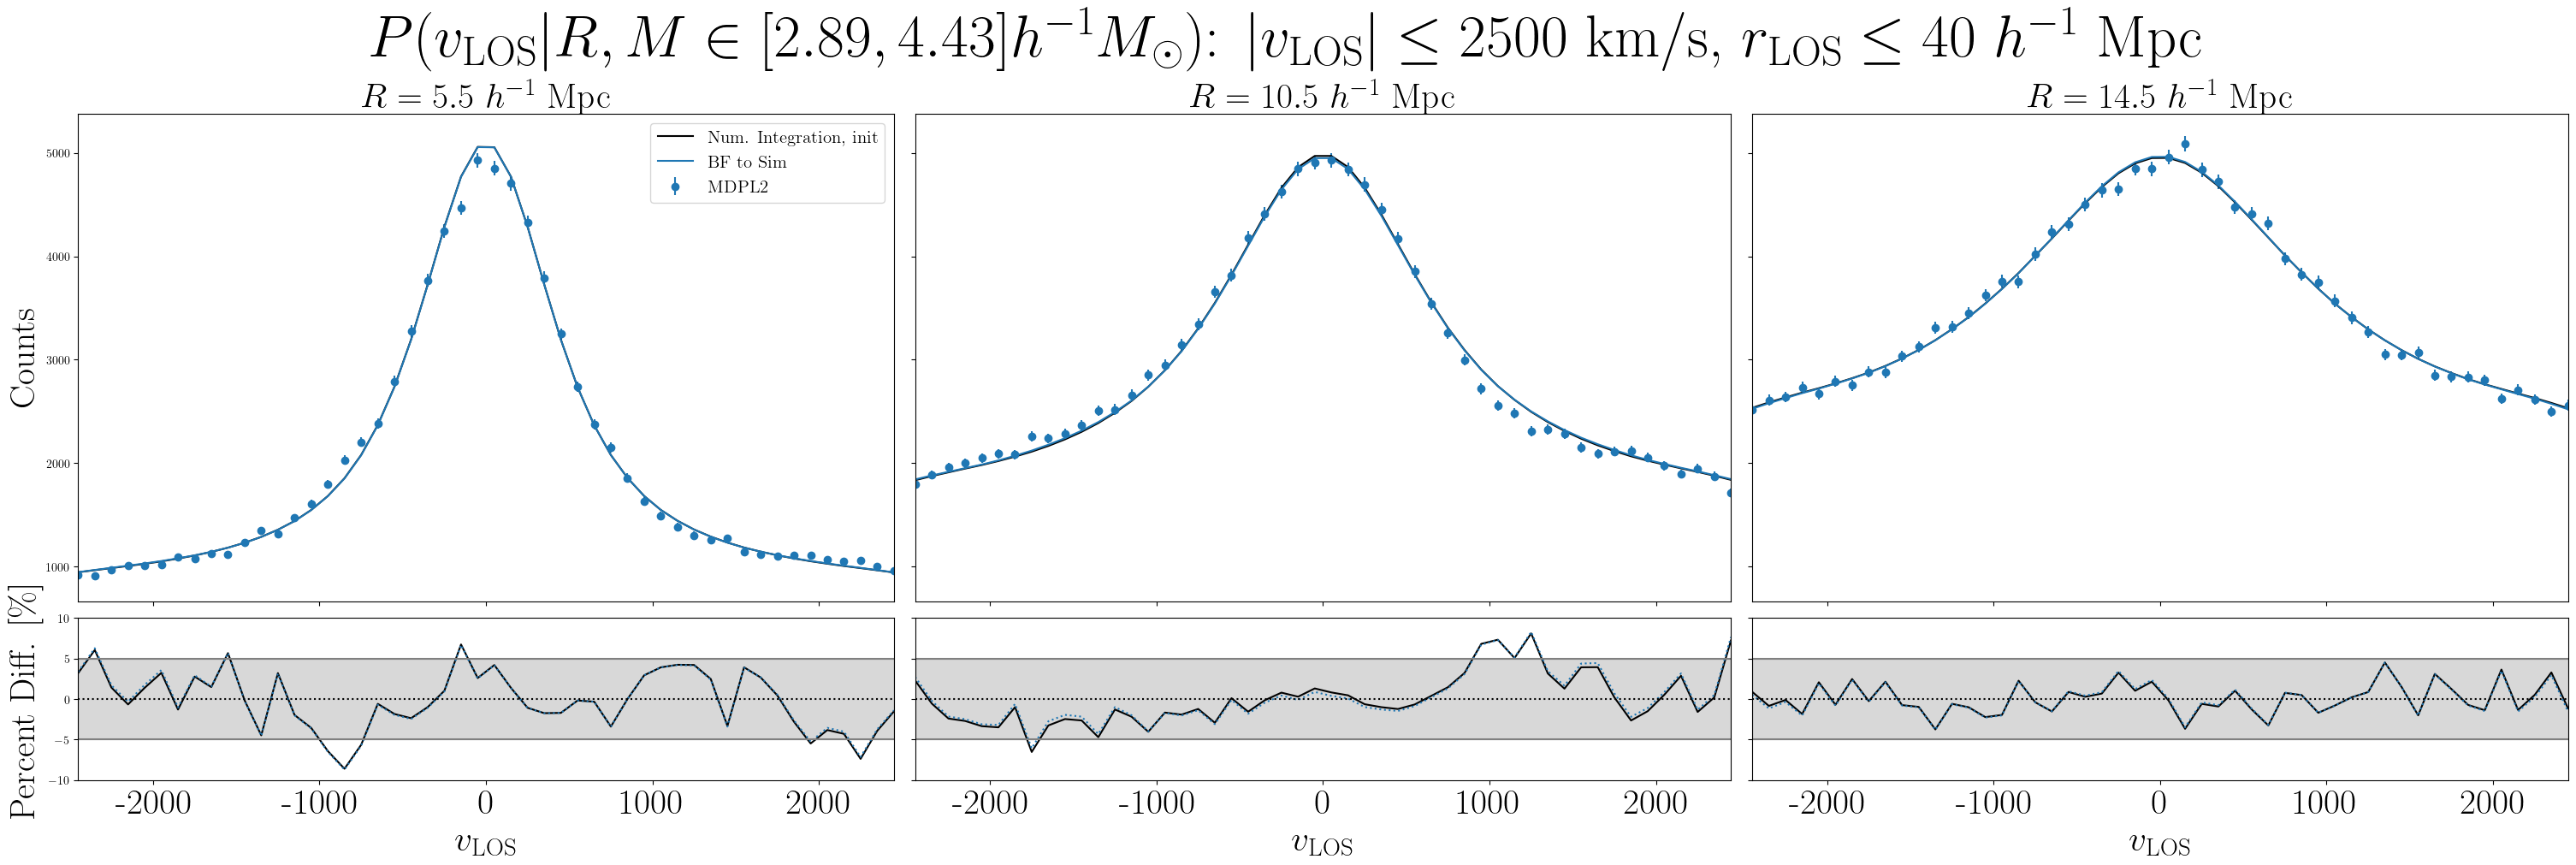

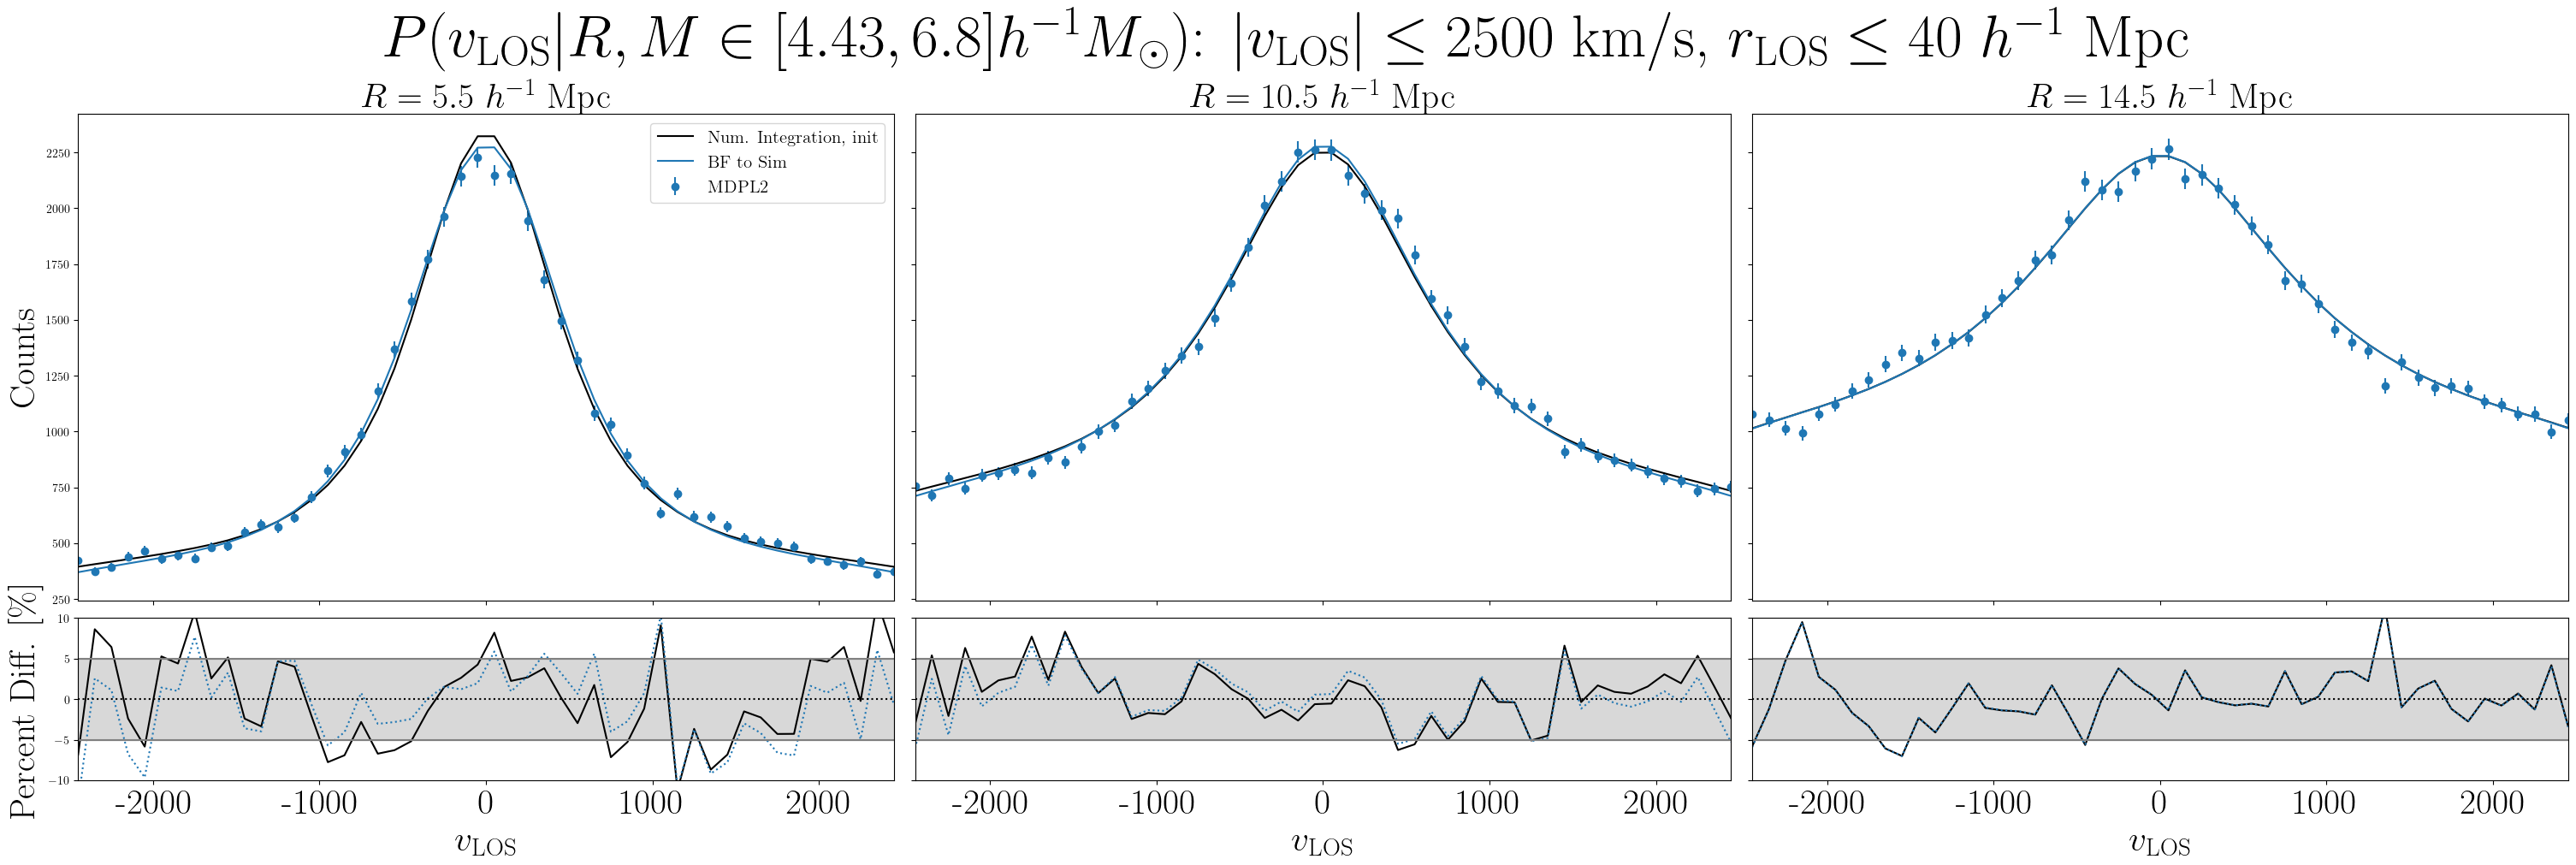

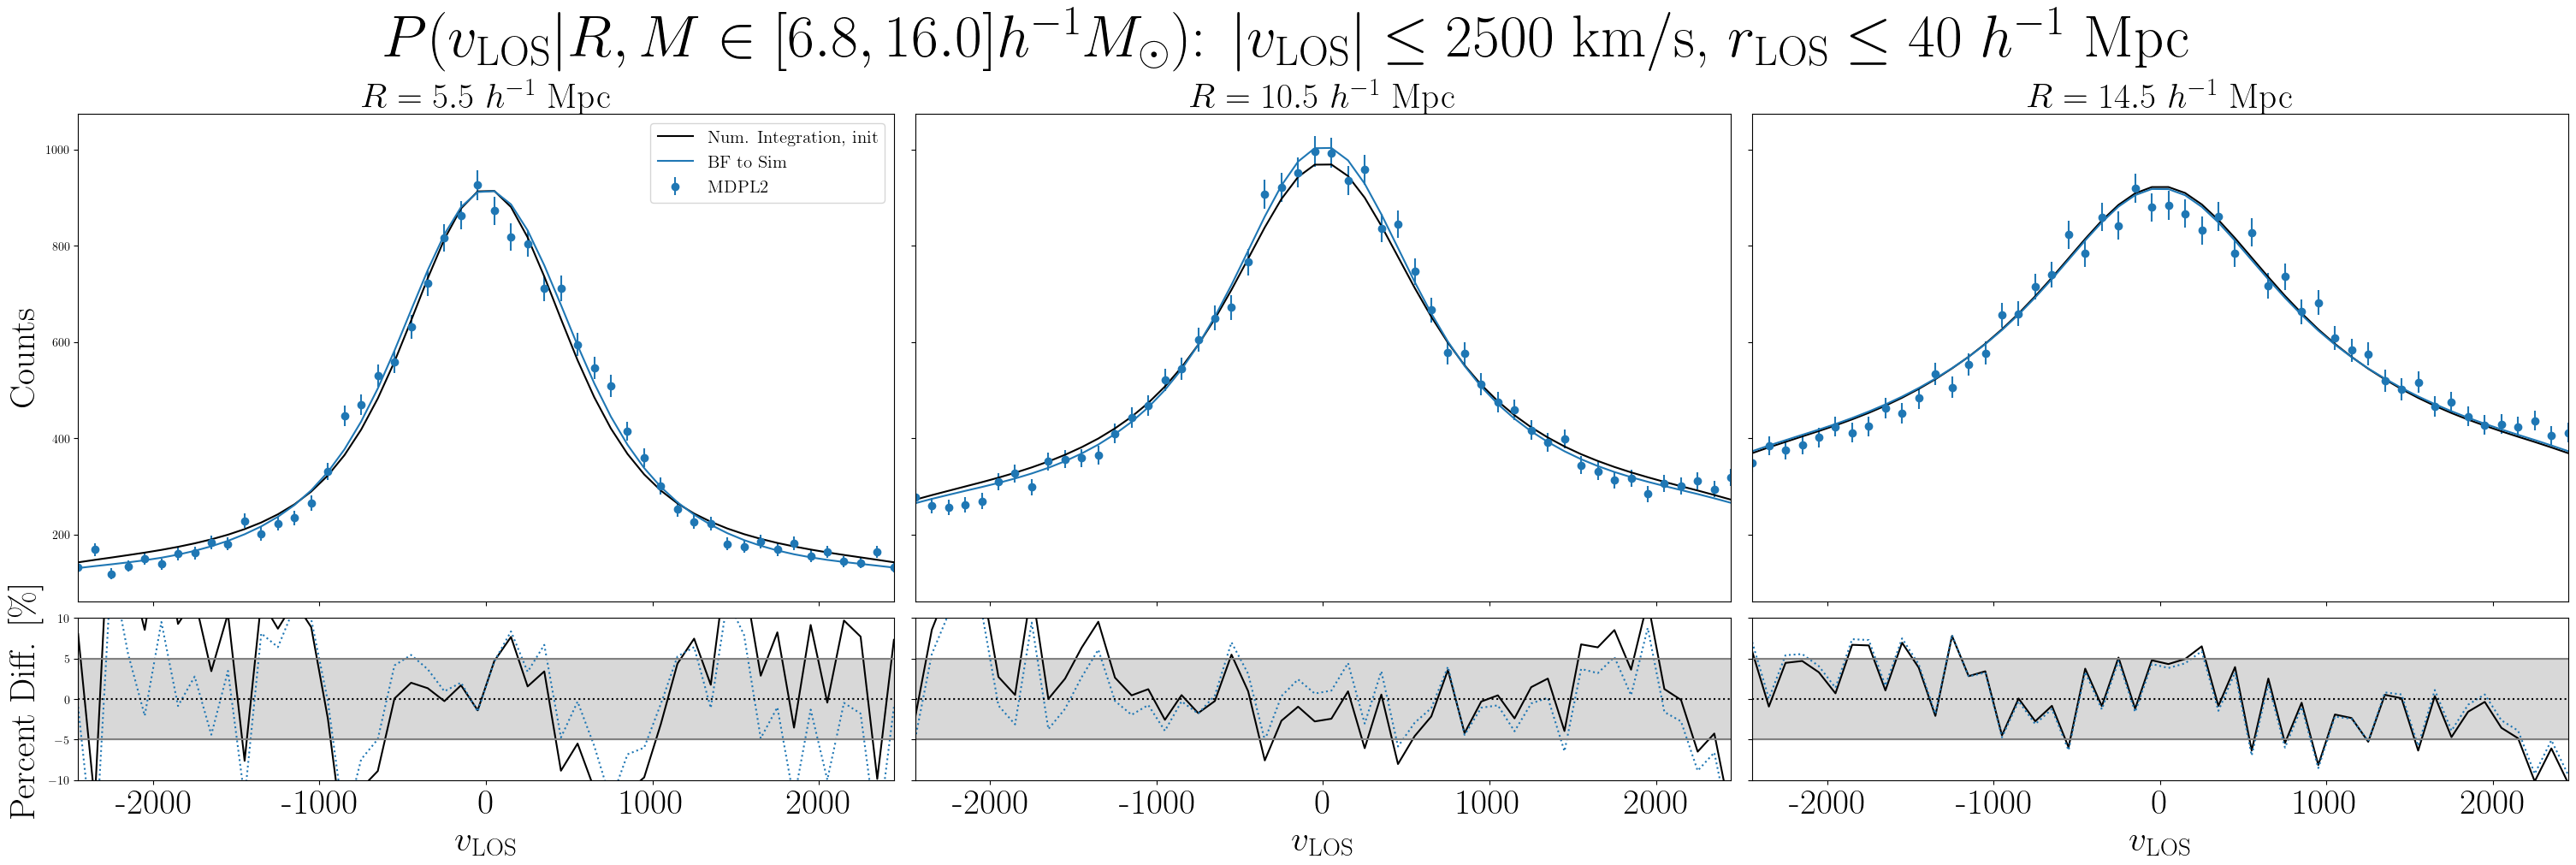

In [20]:
# validate

# check quality of "fit" over mass bins with vlos < 2K km/s 

# compare histograms  
mvirs = Mvirs/1e14
bin_num = 50 #120

r_select_inds = [0, 5, 9]
r_select = np.array([r_cens[i] for i in r_select_inds]) 

#for j in range(1):
for k in range(len(mvirs)):
    #k = 5
    fig, ax = plt.subplots(2, len(r_select), figsize=(30, 10), sharex=True, sharey='row', layout='constrained', gridspec_kw={'height_ratios': [3, 1]}) 
    for i, R in enumerate(r_select):

        index = r_select_inds[i] + k*len(r_cens)
        hist, bins_ex = np.histogram(vphyslos_ls[index], bins=bin_num, range=[-2500, 2500], density=False)
        

        hist_bin, bins_ex = np.histogram(vphyslos_bin[index], bins=bin_num, range=[-2500, 2500], density=False)
        

        #hist_ind, bins_ex = np.histogram(vphyslos_ind[index], bins=bin_num, range=[-2500, 2500], density=False)
        

        vcens_ex = 0.5*(bins_ex[1:]+bins_ex[:-1])

        dist =  P_vphys_R_simdens(vcens, r_select[i], Mvirs[k]) #P_vphys_R_int(Mvals[inds[k]])[:, r_select_inds[i]]
        dist_out = mc.P_vphys_R_int(mc.par_mass_ind[k, r_select_inds[i], 0])[:, r_select_inds[i]]
        #dist = dist / np.sum(dist*np.diff(vcens_ex)[0]) 

        # dist2 = P_vphys_R_int(par_mass_ind[1, k, i, 0])[:, r_select_inds[i]]
        # dist2 = dist2 / np.sum(dist2*np.diff(vcens_ex)[0])

        # dist3 =  P_vphys_R_int(par_mass_ind[2, k, i, 0])[:, r_select_inds[i]]
        # dist3 = dist3 / np.sum(dist3*np.diff(vcens_ex)[0])

        N_avg = np.sum(hist)*dist*np.diff(vcens_ex)[0]
        N_avg2 = np.sum(hist_bin)*dist_out*np.diff(vcens_ex)[0]
        N_avg3 = np.sum(hist)*dist_out*np.diff(vcens_ex)[0]

        ax[0, i].errorbar(vcens_ex, hist, np.sqrt(hist), fmt='o', c=f'C0', label='MDPL2') #
        #ax[0, i].errorbar(vcens_ex, hist_bin, np.sqrt(hist_bin), fmt='o', marker='s', c=f'C1', label='Model Samples') #
        #ax[0, i].errorbar(vcens_ex, hist_ind, np.sqrt(hist_ind), fmt='o', marker='x', c=f'C{str(k)}') #

        ax[0, i].plot(vcens_ex, N_avg, c='k', label='Num. Integration, init')# 
        #ax[0, i].plot(vcens_ex, N_avg2, c='C1', label='BF to MS')# 
        ax[0, i].plot(vcens_ex, N_avg3, c='C0', label='BF to Sim')# 

        ax[0, i].set_title(r"$R={} \ h^{{-1}}$ Mpc".format(R), fontsize=30)
        ax[0, i].margins(x=0)

        ax[1, i].plot(vcens_ex, (N_avg - hist)/hist * 100, c='k')
        #ax[1, i].plot(vcens_ex, (N_avg2 - hist_bin)/hist_bin * 100, c='C1')
        ax[1, i].plot(vcens_ex, (N_avg3 - hist)/hist * 100, ls=':', c='C0')

        #print(np.sum((N_avg - hist)**2/hist ), np.sum((N_avg3 - hist)**2/hist ))
        ax[1, i].axhline(0.0, c='k', ls=':')
        ax[1, i].axhline(5, c='gray', ls='-')
        ax[1, i].fill_between(vcens_ex, 5, -5, color='gray', alpha=0.3)
        ax[1, i].axhline(-5, c='gray', ls='-')
        ax[1, i].set_ylim((-10, 10))
        ax[1, i].margins(x=0)
        ax[1, i].set_xlabel(r'$v_{\rm LOS}$', fontsize=30)
        ax[1, i].set_xticks([-2000, -1000, 0, 1000, 2000])
        ax[1, i].set_xticklabels(['-2000', '-1000', '0', '1000', '2000'], fontsize=30)
    ax[0, 0].legend(loc='upper right', fontsize=15)
    ax[0, 0].set_ylabel(r'Counts', fontsize=30)
    ax[1, 0].set_ylabel(r'Percent Diff. $[\%]$', fontsize=30)
    fig.suptitle(r"$P(v_{{\rm LOS}}|R, M\in[{}, {}] h^{{-1}}M_\odot)$: $|v_{{\rm LOS}}| \leq {}$ km/s, $r_{{\rm LOS}} \leq 40 \ h^{{-1}}$ Mpc".format(round(mbins[k]/1e14, 2), round(mbins[k+1]/1e14, 2), 2500), fontsize=50)  
    

Fitting individual R bins...
Fitting bins simultaneously...


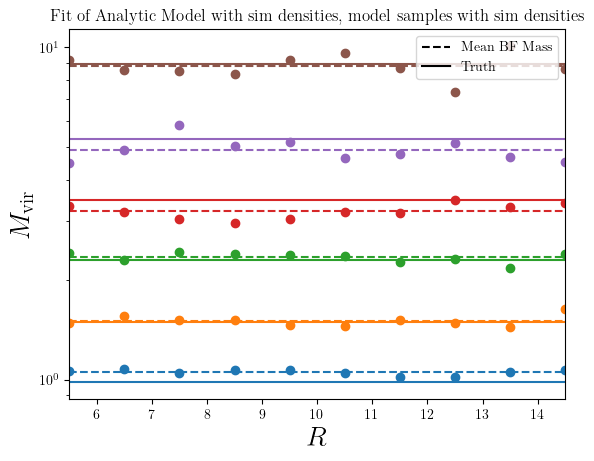

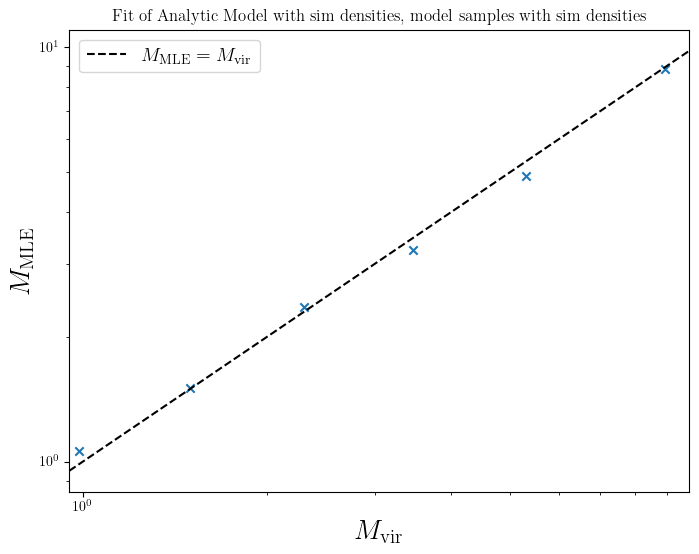

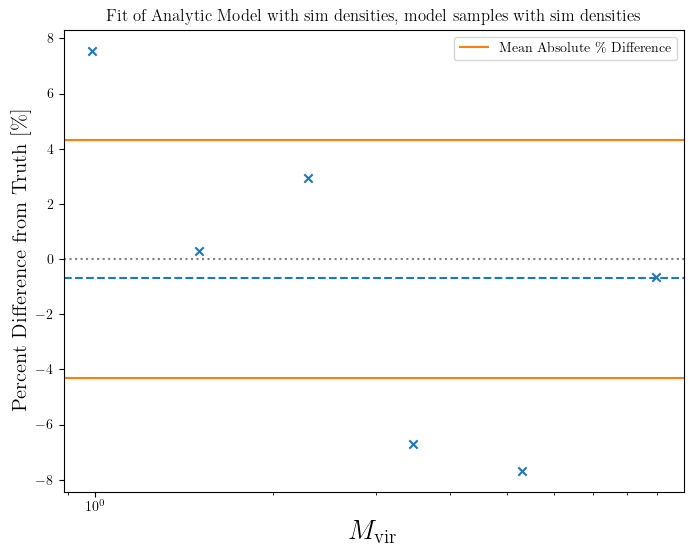

In [39]:
# again with fake data


mc_bin = MassCalibrator(r_cens, 
                    Mvirs, 
                    mbins, 
                    vedges, 
                    LOS_hists_bin, 
                    grid_path='/spiff/cosweeney/simulations/MDPL2/data/Pvlos_simdens_M_grid_R_5_15_gal.npy', 
                    Mvals=Mvals)

mc_bin.calibrate_full()

mc_bin.plot_indiv_fits()
plt.title(r"Fit of Analytic Model with sim densities, model samples with sim densities")

mc_bin.plot_simult_fits()
plt.title(r"Fit of Analytic Model with sim densities, model samples with sim densities")

mc_bin.plot_per_diff()
plt.title(r"Fit of Analytic Model with sim densities, model samples with sim densities")
plt.axhline(np.mean((mc_bin.par_mass_sim[:-1]-mvirs)/mvirs)*100, c='C0', ls='--')


In [27]:
# bin model samples computed with model density
samp_dens_path = '/spiff/cosweeney/simulations/MDPL2/data/Pvlos_models/gal_model_bin_mass_samples_r_5_15_model_dens.hdf5'

vphyslos_dens = []

for k, M in enumerate(Mvirs):
    for i, R in enumerate(r_cens):
        with h5.File(samp_dens_path, 'r') as hdf:
            vphys = hdf[f'vphyslos/{str(k)}/{str(i)}'][()] 

        vphyslos_dens.append(vphys)


# bin data
bin_num = len(vcens)
LOS_hists_dens = np.zeros((bin_num, len(Mvirs), len(r_cens)))

for k in range(len(Mvirs)):
    for i in range(len(r_cens)):
        index = i + len(r_cens)*k

        hist, v_edges = np.histogram(vphyslos_dens[index], bins=bin_num, range=[-2500, 2500], density=False)
        #hist_bin, v_edges = np.histogram(vphyslos_bin[index], bins=bin_num, range=[-2500, 2500], density=False)
 #       hist_ind, v_edges = np.histogram(vphyslos_ind[index], bins=bin_num, range=[-2500, 2500], density=False)

        v_cens = (v_edges[:-1] + v_edges[1:]) / 2 

        LOS_hists_dens[:, k, i] = hist  
        #LOS_hists_bin[:, k, i] = hist_bin 

Fitting individual R bins...
Fitting bins simultaneously...


Text(0.5, 1.0, 'Fit of Analytic Model with sim densities, model samples with model densities')

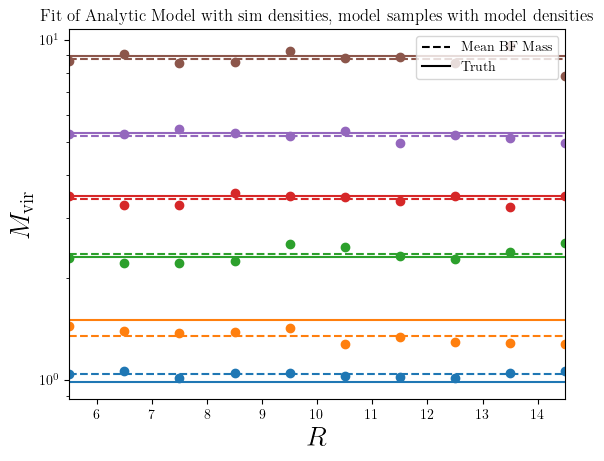

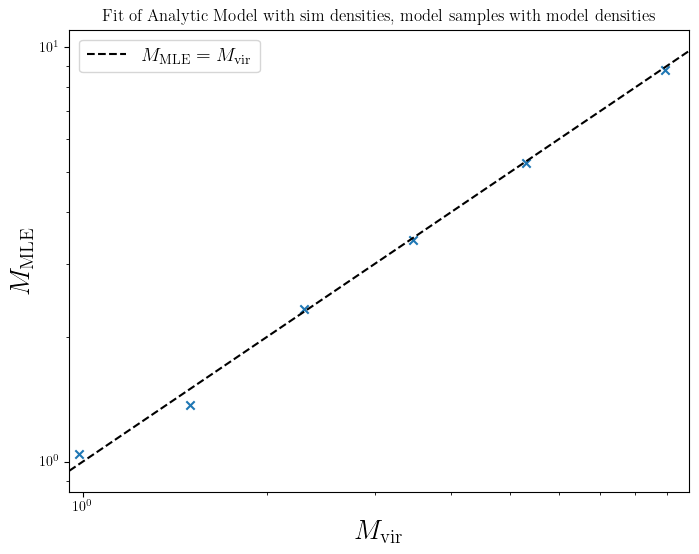

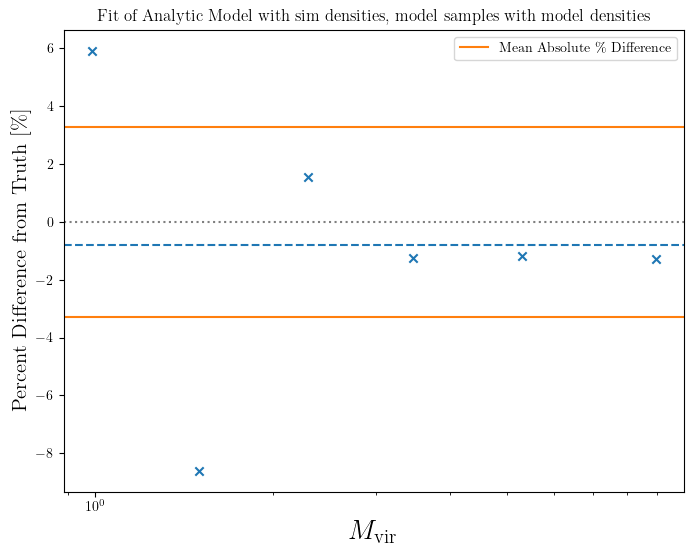

In [40]:
# again with fake data, sim densities


mc_dens = MassCalibrator(r_cens, 
                    Mvirs, 
                    mbins, 
                    vedges, 
                    LOS_hists_dens, 
                    grid_path='/spiff/cosweeney/simulations/MDPL2/data/Pvlos_simdens_M_grid_R_5_15_gal.npy', 
                    Mvals=Mvals)

mc_dens.calibrate_full()

mc_dens.plot_indiv_fits()
plt.title(r"Fit of Analytic Model with sim densities, model samples with model densities")

mc_dens.plot_simult_fits()
plt.title(r"Fit of Analytic Model with sim densities, model samples with model densities")

mc_dens.plot_per_diff()
plt.axhline(np.mean((mc_dens.par_mass_sim[:-1]-mvirs)/mvirs)*100, c='C0', ls='--')
plt.title(r"Fit of Analytic Model with sim densities, model samples with model densities")

<>:2: SyntaxWarning: invalid escape sequence '\%'
<>:2: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_2552259/541612949.py:2: SyntaxWarning: invalid escape sequence '\%'
  plt.axhline(np.mean((mc_dens.par_mass_sim[:-1]-mvirs)/mvirs)*100, c='C0', ls='--', label='Mean $\%$ Difference' )


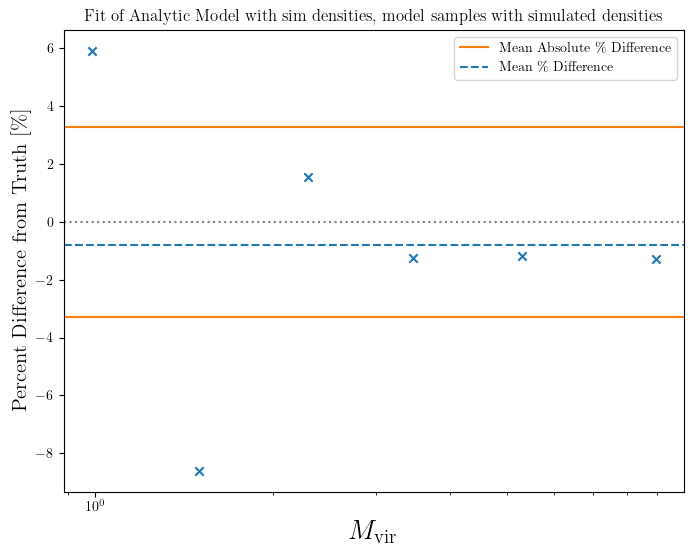

In [38]:

mc_dens.plot_per_diff()
plt.axhline(np.mean((mc_dens.par_mass_sim[:-1]-mvirs)/mvirs)*100, c='C0', ls='--', label='Mean $\%$ Difference' )
plt.title(r"Fit of Analytic Model with sim densities, model samples with simulated densities")
plt.legend()